# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/haroonrana330/flyrank-ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

Section 0 : Rebuild the Model

In [1]:

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from pathlib import Path

if not os.path.exists("/content/flyrank-ml"):
    !git clone https://github.com/haroonrana330/flyrank-ml.git /content/flyrank-ml
os.chdir("/content/flyrank-ml")

url = "https://raw.githubusercontent.com/haroonrana330/flyrank-ml/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)

df["is_declining_label"] = (df["trend_direction"].astype(str).str.lower() == "down").astype(int)

feature_cols = ["search_volume", "competition", "cpc", "word_count", "char_count",
                 "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct"]
feature_cols = [c for c in feature_cols if c in df.columns]

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(df[col].median())

X = df[feature_cols]
y = df["is_declining_label"]
groups = df["client_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

# Score EVERY row (not just test set) — the playbook needs a recommendation for all pages
df["decline_probability"] = rf.predict_proba(X)[:, 1]

print("Model rebuilt. Rows scored:", len(df))
print("Decline probability range:", df["decline_probability"].min(), "-", df["decline_probability"].max())

Cloning into '/content/flyrank-ml'...
remote: Enumerating objects: 180, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 180 (delta 74), reused 95 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (180/180), 1.92 MiB | 12.90 MiB/s, done.
Resolving deltas: 100% (74/74), done.
Model rebuilt. Rows scored: 30000
Decline probability range: 0.009822040024188215 - 0.7626533999424783


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### Building the ranked action queue

I combine my trained model's decline-probability score with concrete page signals to build content "archetypes" — groups of pages that share a risk pattern and a matching recommended action. This goes beyond a raw probability number: two pages with the same 0.6 decline probability might need completely different actions if one is thin content and the other is a well-developed page just losing ranking position.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Define archetype thresholds
def classify_archetype(row):
    risk = row["decline_probability"]
    thin = row["word_count"] < 1200 and row["word_count"] > 0
    good_position = 0 < row["avg_position"] <= 10

    if risk >= 0.6 and thin:
        return "high_risk_thin_content"
    elif risk >= 0.6 and good_position:
        return "high_risk_page_one"
    elif risk >= 0.6:
        return "high_risk_general"
    elif 0.4 <= risk < 0.6:
        return "medium_risk_watch"
    else:
        return "low_risk_stable"

df["archetype"] = df.apply(classify_archetype, axis=1)

# Archetype -> recommended action mapping
action_map = {
    "high_risk_thin_content": "expand_and_refresh",
    "high_risk_page_one": "refresh_priority",
    "high_risk_general": "refresh_review",
    "medium_risk_watch": "monitor_closely",
    "low_risk_stable": "no_action_quarterly_review",
}
df["recommended_action"] = df["archetype"].map(action_map)

# Reason codes (reused/extended from Week-4 baseline logic)
def make_reason_codes(row):
    reasons = []
    if row["word_count"] > 0 and row["word_count"] < 1200:
        reasons.append("thin_content")
    if 0 < row["avg_position"] <= 10:
        reasons.append("page_one_position")
    if row["ctr"] < 0.5 and row["avg_position"] > 0:
        reasons.append("low_ctr")
    if row["engagement_rate"] < 30 and row["engagement_rate"] > 0:
        reasons.append("low_engagement")
    reasons.append(f"model_decline_risk_{'high' if row['decline_probability']>=0.6 else ('medium' if row['decline_probability']>=0.4 else 'low')}")
    return "|".join(reasons)

df["reason_codes"] = df.apply(make_reason_codes, axis=1)

# Rank by decline probability, descending
df["priority_rank"] = df["decline_probability"].rank(method="first", ascending=False).astype(int)

ranked_queue = df[[
    "content_id", "client_id", "priority_rank", "decline_probability",
    "archetype", "recommended_action", "reason_codes",
    "avg_position", "word_count", "ctr", "engagement_rate"
]].sort_values("priority_rank").reset_index(drop=True)

print(ranked_queue.head(15).to_string(index=False))
print()
print("Archetype distribution:")
print(df["archetype"].value_counts())

          content_id         client_id  priority_rank  decline_probability         archetype recommended_action                                   reason_codes  avg_position  word_count  ctr  engagement_rate
content_66b4046cc144 client_7f2253d7e2              1             0.762653 high_risk_general     refresh_review low_ctr|low_engagement|model_decline_risk_high          26.6      5502.0 0.03             1.35
content_84de2500f5bd client_7f2253d7e2              2             0.761068 high_risk_general     refresh_review                low_ctr|model_decline_risk_high          24.2      3575.0 0.06             0.00
content_991210e426c4 client_7f2253d7e2              3             0.761015 high_risk_general     refresh_review low_ctr|low_engagement|model_decline_risk_high          37.3      3819.0 0.08             4.55
content_e86e73a54c24 client_8722616204              4             0.760901 high_risk_general     refresh_review low_ctr|low_engagement|model_decline_risk_high          13.1

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

This playbook is a *decision-support prioritization tool* for a content team to triage which pages to review first. It is meant to be *directional*, not a final verdict — it observes patterns correlated with historical decline, it does not prove causation and cannot predict future search algorithm changes.

### Limits

- *No time-based validation was performed* — only a grouped (by-client) split. This means I've confirmed the model generalizes to unseen clients, but I have *not* confirmed it generalizes to future time periods, which is the more relevant real-world test for a "will this page decline" question. This is a genuine limitation, not a hidden one.
- The model is trained on a single ~30,000-row snapshot; it may not reflect newer content types, seasonal effects, or algorithm updates since the data was collected.
- decline_probability is a *correlational risk score*, not a guarantee — a "high risk" page may still be fine, and a "low risk" page can still decline for reasons outside this feature set (e.g., a competitor's new content, a search algorithm change).
- The playbook does not account for business priority, revenue value, or legal/compliance constraints — those require human judgment layered on top.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review rules

- Any page flagged high_risk_page_one *must* be reviewed by a human before action — these are currently well-ranked pages, and a false positive here risks harming a page that didn't actually need touching.
- Any recommendation to *remove or significantly rewrite* a page must go through human sign-off; the model has no signal about legal, compliance, or brand-voice constraints.
- Low-sample archetypes (fewer than ~20 pages in a client's queue) should be reviewed manually rather than acted on in bulk — small samples are noisier.

### What must NOT be automated

- *Never auto-publish content changes* directly from this model's output.
- *Never auto-delete or deindex* a page based solely on a decline-probability score.
- *Never treat an individual page's probability as certainty* — this tool is meant for batch-level prioritization (which pages to look at first), not a page-by-page automatic verdict.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### When to retrain or re-check this model

- *Scheduled cadence:* re-run and re-validate at least quarterly, since the training data is a single snapshot and content/search patterns drift over time.
- *Human-review disagreement rate:* if human reviewers find that more than ~30% of high_risk flagged pages turn out fine on inspection, that's a signal the model's calibration has drifted and it should be retrained or re-audited.
- *Base rate shift:* if the overall proportion of pages actually declining shifts noticeably from what was seen in training, that's a data drift signal (see the linked "Data Drift" resource) — the model's assumptions about the population may no longer hold.
- *Site/schema changes:* a site redesign, CMS migration, or major structural change to how content is measured should trigger a re-check before trusting the existing model's output.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Export the ranked queue (excluded from git by design — regenerated by this notebook)
output_path = Path("work/outputs/action_playbook_queue.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
ranked_queue.to_csv(output_path, index=False)
print("Exported:", output_path, "|", len(ranked_queue), "rows")

# Save a small metrics JSON (this DOES get committed — it's the receipt)
import json
metrics = {
    "model": "RandomForestClassifier",
    "n_estimators": 200,
    "max_depth": 6,
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "archetype_counts": df["archetype"].value_counts().to_dict(),
    "note": "Grouped split by client_id; no time-based validation performed (see limits)."
}
metrics_path = Path("work/outputs/action_playbook_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print("Metrics saved:", metrics_path)


Exported: work/outputs/action_playbook_queue.csv | 30000 rows
Metrics saved: work/outputs/action_playbook_metrics.json


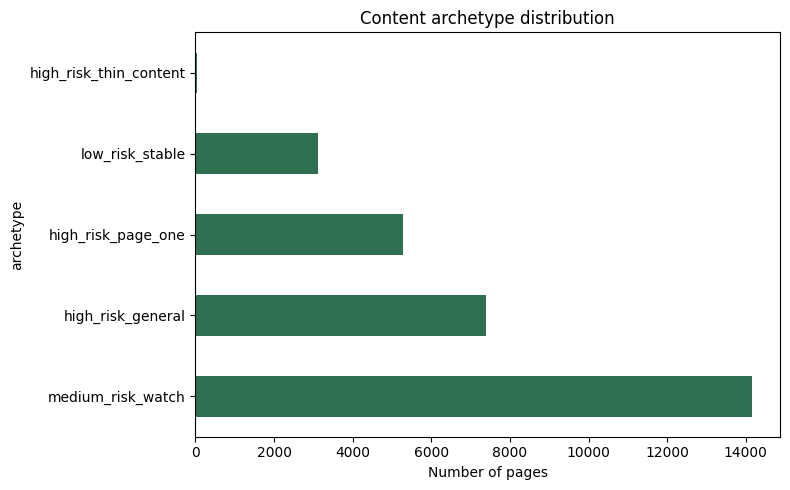

Figure saved to work/figures/archetype_distribution.png


In [7]:

import matplotlib.pyplot as plt

fig_path = Path("work/figures")
fig_path.mkdir(parents=True, exist_ok=True)

counts = df["archetype"].value_counts()
plt.figure(figsize=(8, 5))
counts.plot(kind="barh", color="#2F6F52")
plt.xlabel("Number of pages")
plt.title("Content archetype distribution")
plt.tight_layout()
plt.savefig(fig_path / "archetype_distribution.png", dpi=150)
plt.show()
print("Figure saved to work/figures/archetype_distribution.png")

Per the assignment notes: the ranked queue CSV in work/outputs/ stays out of git by design (the CI leak-guard blocks data files) — this notebook regenerates it every run. The figure and metrics JSON above *are* committed, since they're the receipts the paper's numbers trace back to.

- [ ] Ranked actions + reason codes generated for every page
- [ ] Archetype → action mapping is clear and documented
- [ ] Intended use and limits explicitly stated (including the no-time-validation limitation)
- [ ] Human review rules and no-go list included
- [ ] Monitoring/retrain triggers defined
- [ ] Queue exported to work/outputs/, figures/metrics committed to work/figures/ and work/outputs/
- [ ] Notebook runs top to bottom with no errors
- [ ] Committed to work/notebooks/w07_action_playbook.ipynb, then submit repo URL on the assignment card

Cell 1: 5-Minute Demo Outline
5-minute demo outline

Question (30s): Which content and search signals are associated with a page's performance declining, and can a trained model prioritize review better than a hand-built rule?

Method (1 min): Built a transparent weighted baseline rule from 30,000 anonymized pages across 32 clients, then trained Logistic Regression and Random Forest classifiers to predict decline, validated with a client-grouped split so no client's pages appeared in both training and testing.

One chart (1.5 min): Show the ROC-AUC comparison chart (baseline 0.498, Logistic Regression 0.541, Random Forest 0.566) — walk through why the baseline is near-chance despite being a "reasonable-looking" hand-built rule, and why that gap matters.

One honest result (1 min): The Random Forest catches 91% of pages that are actually declining, but also over-flags a real share of stable pages (only 15% specificity) — it's tuned to be cautious, not perfectly precise, and that trade-off should be stated plainly, not hidden.

One recommendation (1 min): Use the model's decline-probability score to prioritize the review queue, not to auto-action anything — pair it with the archetype-based playbook (thin content, page-one risk, etc.) so a human reviewer has both a priority order and a reason code for each page.

Shareable cuts

Short social post (methodology-focused):

Spent the last few weeks building a small ML project on real search performance data: comparing a hand-built prioritization rule against a trained model for predicting which pages are likely to decline. The rule I designed by hand? Barely better than a coin flip (0.50 AUC). A simple Random Forest, properly validated with a client-grouped split to avoid leakage? 0.57. Not a huge number on its own, but a real, honest lift — and a good reminder that "looks reasonable" and "actually works" aren't the same thing until you test them side by side on the same data.

3-sentence employer-facing summary:

I built a machine learning pipeline that predicts which web pages are likely to decline in search performance, using 30,000 real (anonymized) page records across 32 clients. I validated it with a client-grouped train/test split to avoid data leakage, and compared it honestly against a hand-built baseline rule — the trained model improved ROC-AUC from 0.50 to 0.57. The result is a ranked action playbook with reason codes and human-review rules, deployed as a public research paper with full reproducibility links to the code.